In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

import warnings 
warnings.filterwarnings("ignore") 

In [2]:
Weight = np.array([64,53,71,67,55,58,77,57,56,51,76,68])
Height = np.array([57,49,59,62,51,50,55,48,52,42,61,57])
Age    = np.array([8,6,10,11,8,7,10,9,10,6,12,9])

df = pd.DataFrame({"Weight": Weight, "Height": Height, "Age": Age})
X = df[['Height', 'Age']]
y = df['Weight']

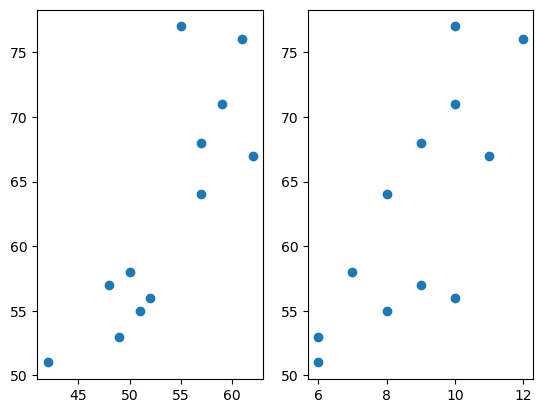

In [3]:
plt.subplot(1,2,1)
plt.scatter(X['Height'], y)

plt.subplot(1,2,2)
plt.scatter(X['Age'], y)

In [4]:
model= LinearRegression().fit(X, y)

In [5]:
# Regression Intercept and coefficients
b0 = model.intercept_
b1, b2 = model.coef_
print(f'β₀ = {b0:.4f}', f'β₁ = {b1:.4f}', f'β₂ = {b2:.4f}')

β₀ = 3.6512 β₁ = 0.8546 β₂ = 1.5063


In [6]:
y_pred = model.predict(X)
print('Estimated weights:', y_pred)

Estimated weights: [64.41464032 54.56509625 69.13652482 73.20668693 59.28698075 56.9260385
 65.71808511 58.22948328 63.15425532 48.58282675 73.85840932 65.92097264]


In [7]:
# E.g: Estimate the weight of a 9 year old who is 54 inches tall
Estimated_weight = model.predict([[54, 9]])
print('Estimated weight=', Estimated_weight)

Estimated weight= [63.35714286]


# Multiple Linear Regression Plot

Text(0.5, 0, 'Weight [pounds]')

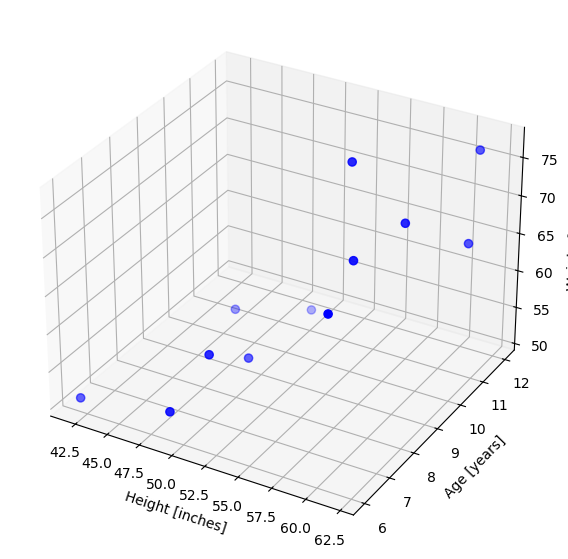

In [8]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

x1 = X['Height']
x2 = X['Age']

ax.scatter(x1, x2, y, marker='o', s=35, color='b', label='True Data')
ax.set_xlabel('Height [inches]')
ax.set_ylabel('Age [years]')
ax.set_zlabel('Weight [pounds]')

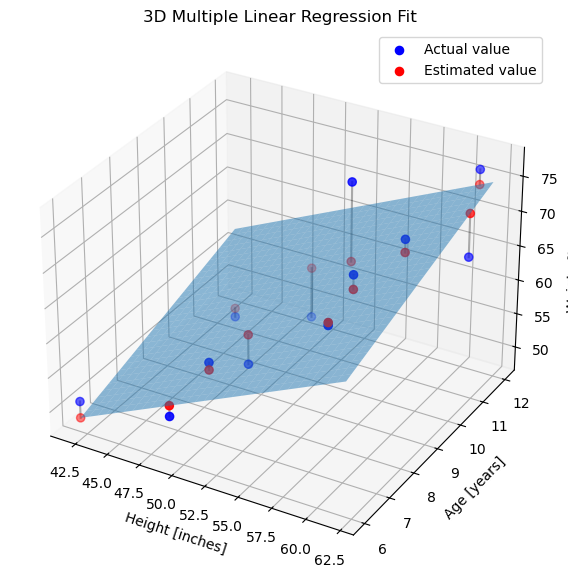

In [10]:
# meshgrid
x_range = np.linspace(df['Height'].min(), df['Height'].max(), 30)     # (40, 65, 30)       
y_range = np.linspace(df['Age'].min(), df['Age'].max(), 30)           # (5, 13, 30)
xx, yy = np.meshgrid(x_range, y_range)
# zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
zz = b0 + b1*xx + b2*yy

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Height'], df['Age'], df['Weight'], s=35, color='b', label='Actual value')

# Plot regression plane
ax.plot_surface(xx, yy, zz, alpha=0.5)       # rstride=30, cstride=30
 
# Plot fitted points
z_fitted = b0 + b1*x1 + b2*x2
ax.scatter(x1, x2, z_fitted, c='r', s=35, label='Estimated value')

for i in range(len(df)):
    ax.plot([x1[i], x1[i]], [x2[i], x2[i]], [y[i], z_fitted[i]], 'k-', alpha=0.3)

ax.set_xlabel('Height [inches]')
ax.set_ylabel('Age [years]')
ax.set_zlabel('Weight [lpounds]')
ax.set_title('3D Multiple Linear Regression Fit')
ax.legend()

# plt.savefig('Multi_Regression.png', dpi=500, bbox_inches='tight')
plt.show()

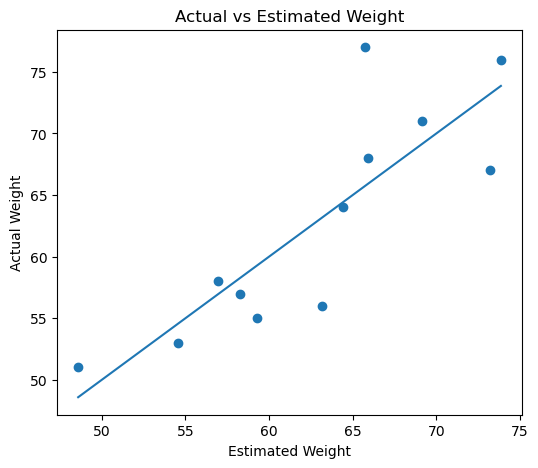

In [11]:
# Plot Actual vs Estimated
plt.figure(figsize=(6,5))
plt.scatter(y_pred, y)
plt.xlabel("Estimated Weight")
plt.ylabel("Actual Weight")
plt.title("Actual vs Estimated Weight")
plt.plot([y_pred.min(), y_pred.max()],
         [y_pred.min(), y_pred.max()])

# plt.savefig('z vs z_Estimated.png', dpi=500, bbox_inches='tight')
plt.show()

In [12]:
import statsmodels.formula.api as smf

data = {
    'Weight_z': [64, 53, 71, 67, 55, 58, 77, 57, 56, 51, 76, 68],
    'Height_x': [57, 49, 59, 62, 51, 50, 55, 48, 52, 42, 61, 57],
    'Age_y': [8, 6, 10, 11, 8, 7, 10, 9, 10, 6, 12, 9]
}
df = pd.DataFrame(data)

model = smf.ols('Weight_z ~ Height_x + Age_y', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Weight_z   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     10.94
Date:                Mon, 08 Dec 2025   Prob (F-statistic):            0.00390
Time:                        09:10:09   Log-Likelihood:                -35.456
No. Observations:                  12   AIC:                             76.91
Df Residuals:                       9   BIC:                             78.37
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.6512     16.168      0.226      0.8